In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression   # ⬅️ new
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)  # ⬅️ new
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\SEM_VI\PATTERN_REC\weather_forecast_data.csv")
print(df.shape)
print(df.head())
print(df['Rain'].value_counts())

(2500, 6)
   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain
Rain
no rain    2186
rain        314
Name: count, dtype: int64


In [3]:
le = LabelEncoder()
df['Rain'] = le.fit_transform(df['Rain'])

X = df.drop('Rain', axis=1)
y = df['Rain']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # ⬅️ probability scores for ROC

0.932
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       443
           1       0.73      0.63      0.68        57

    accuracy                           0.93       500
   macro avg       0.84      0.80      0.82       500
weighted avg       0.93      0.93      0.93       500

ROC AUC: 0.9583


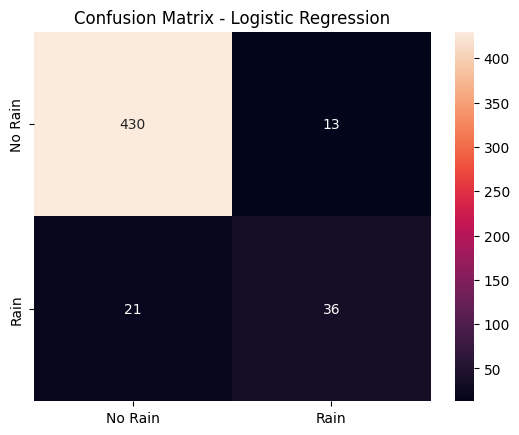

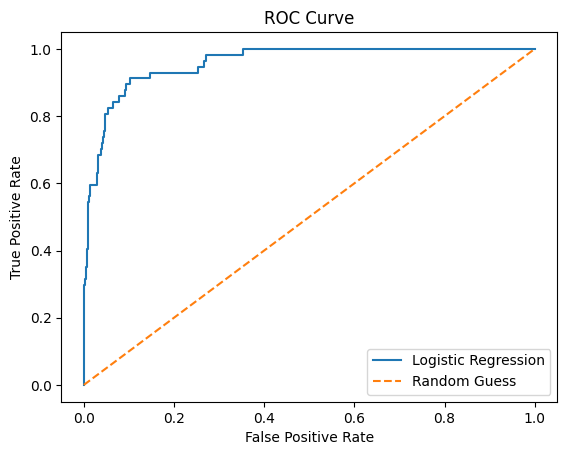

In [5]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Rain','Rain'],
            yticklabels=['No Rain','Rain'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], '--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()